In [121]:
# URL to import data set from GitHub.
url = 'https://raw.githubusercontent.com/fourthrevlxd/cam_dsb/main/engine.csv'

# Mini-Project 5.3 — Anomaly Detection in Ship Engine Data

## Project Overview

This notebook develops an anomaly detection system to evaluate the operational health of a ship's engine. The engine is monitored across six continuous sensor readings: Engine RPM, Lubrication Oil Pressure, Fuel Pressure, Coolant Pressure, Lubrication Oil Temperature, and Coolant Temperature.

Anomalies in these readings can signal mechanical failures, safety hazards, and costly downtime. The goal is to identify abnormal combinations of sensor readings since the business context highlights that anomalies typically emerge from the interaction of multiple features simultaneously.

The analysis follows three stages:
1. **Exploratory Data Analysis (EDA)** — understanding the distribution and structure of the data
2. **Statistical Anomaly Detection** — using the Interquartile Range (IQR) method
3. **Machine Learning Anomaly Detection** — using One-Class SVM and Isolation Forest
4. **Cross Method Comparison and Findings**
5. **Anomaly Profiling Observations**

In [122]:
#Install Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import OneClassSVM
from sklearn.ensemble import IsolationForest

In [123]:
#Load datatset

data = pd.read_csv(url)

data.head()


,Engine rpm,Lub oil pressure,Fuel pressure,Coolant pressure,lub oil temp,Coolant temp
0,682,2.391656,4.617196,2.848982,76.272417,69.884609
1,605,5.466877,6.424361,5.727520,73.222679,74.907314
2,658,3.434232,3.680896,1.678708,88.089916,78.704806
3,749,2.094656,7.120927,1.639670,77.661625,82.386700
4,676,3.538228,5.956472,3.225336,75.226352,67.153220


In [124]:
data.shape

(19535, 6)

### **1. Exploratory Data Analysis**

In [125]:
#Check for missing values and duplicates

null = data.isnull().sum()
duplicate = data.duplicated().sum()

print(f'Null values: {null.sum()}')
print(f'Duplicate values: {duplicate.sum()}')




Null values: 0
Duplicate values: 0


In [126]:
#Data Types

data.dtypes

,0
Engine rpm,int64
Lub oil pressure,float64
Fuel pressure,float64
Coolant pressure,float64
lub oil temp,float64
Coolant temp,float64


**Early Findings**

- No missing values or duplicates in the dataset
-  No Categorical Variables in the dataset


### **1.1Descriptive Statistics**

In [127]:
#Compare the median to the mean
stats = data.describe().T

stats['median'] = data.median()

stats['skewness'] = data.skew()
stats['Mean-Median diff'] = stats['mean'] - stats['median']

stats.round(3)



,count,mean,std,min,25%,50%,75%,max,median,skewness,Mean-Median diff
Engine rpm,19535.0,791.239,267.611,61.000,593.000,746.000,934.000,2239.000,746.000,0.935,45.239
Lub oil pressure,19535.0,3.304,1.022,0.003,2.519,3.162,4.055,7.266,3.162,0.196,0.142
Fuel pressure,19535.0,6.656,2.761,0.003,4.917,6.202,7.745,21.138,6.202,1.216,0.454
Coolant pressure,19535.0,2.335,1.036,0.002,1.600,2.167,2.849,7.479,2.167,1.309,0.168
lub oil temp,19535.0,77.643,3.111,71.322,75.726,76.817,78.072,89.581,76.817,1.496,0.826
Coolant temp,19535.0,78.427,6.207,61.673,73.895,78.347,82.915,195.528,78.347,0.404,0.081


### **Observations**

- Engine RPM has the largest mean-median gap at 45 points (mean: 791, median: 746), and a skewness score of 0.935, confirming a right-skewed distribution where a small number of extremely high RPM values are pulling the mean upward. The maximum RPM of 2,239 is almost three times the median, suggesting these extreme values are significant outliers rather than typical operating conditions.

- Coolant Temperature, despite a seemingly moderate std of 6.2, has a maximum of 195°C. This is nearly 120 degrees above the mean, a difference that would represent a critical overheating event in a real engine. This highlights why visual inspection through boxplots and histograms is essential alongside summary statistics.


## **1.2 Visualisations**

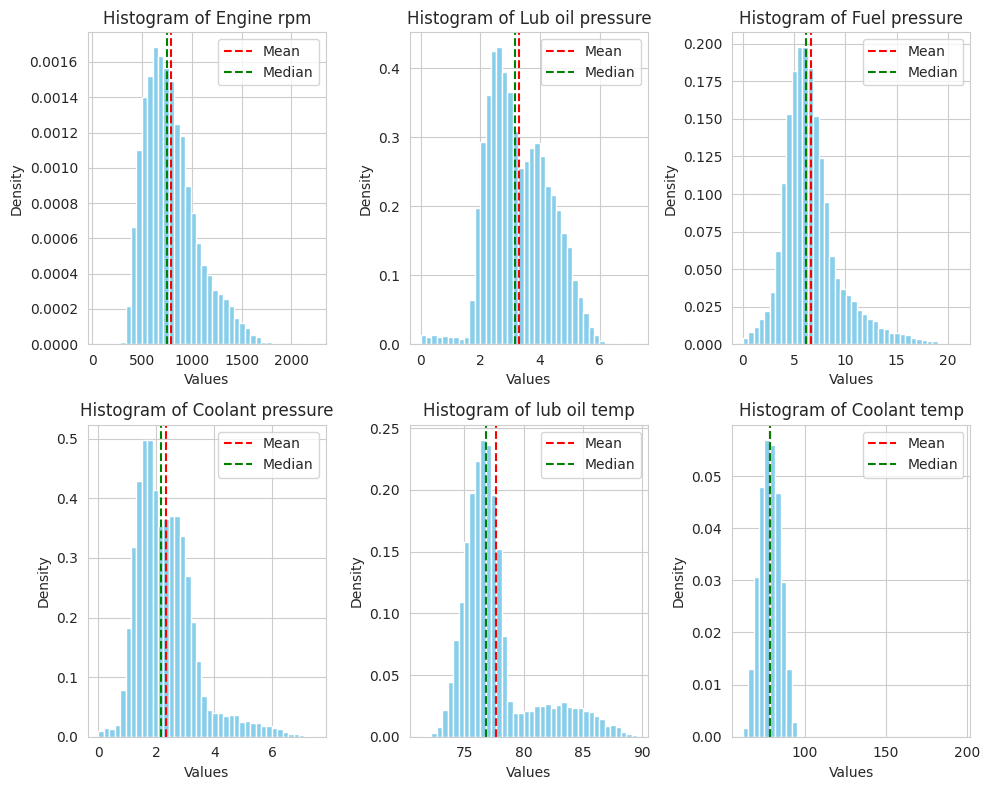

In [128]:
# Histogram

#create a list for features

# Explicitly define features to include only the original sensor readings
features = ['Engine rpm', 'Lub oil pressure', 'Fuel pressure', 'Coolant pressure', 'lub oil temp', 'Coolant temp']

#create a subplot for each feature

sns.set_style('whitegrid')
fig, axes = plt.subplots(2, 3, figsize=(10, 8))
axes = axes.flatten()


for i, feat in enumerate(features):

  axes[i].hist(data[feat], bins=40, color='skyblue', density=True)
  axes[i].axvline(data[feat].mean(), color='red', linestyle='dashed', linewidth=1.5, label='Mean')
  axes[i].axvline(data[feat].median(), color='green', linestyle='dashed', linewidth=1.5, label='Median')
  axes[i].set_title(f'Histogram of {feat}')
  axes[i].set_xlabel('Values')
  axes[i].set_ylabel('Density')
  axes[i].legend()

plt.tight_layout()
plt.savefig('Histogram plots of all features.png',bbox_inches='tight')

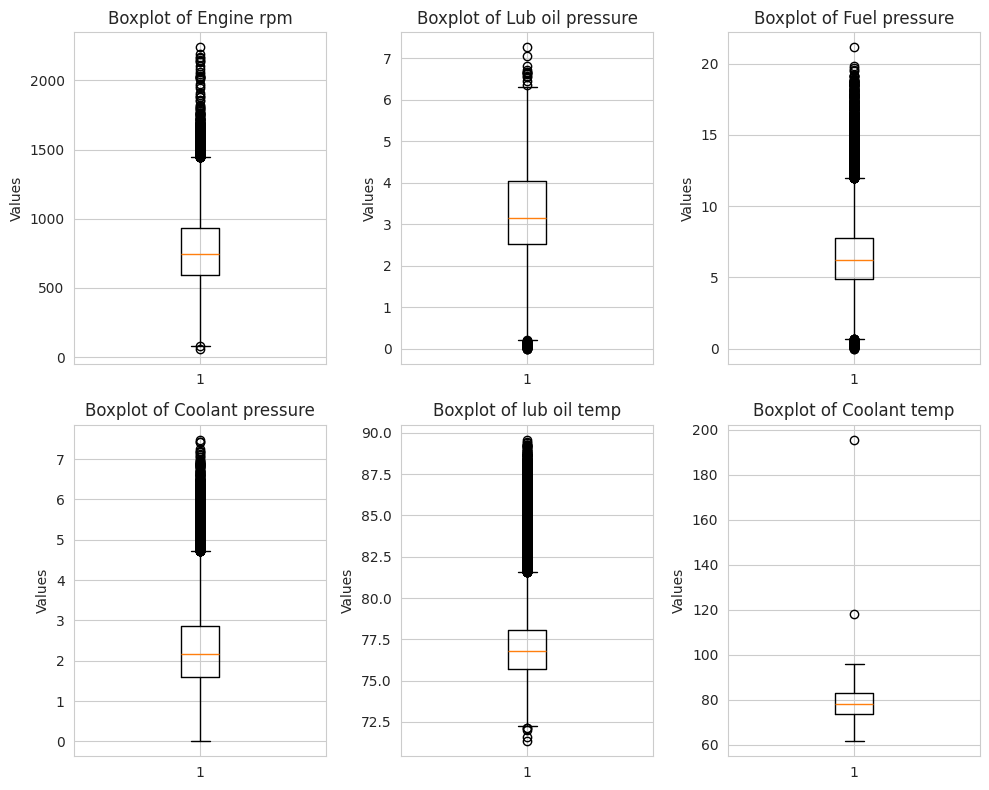

In [129]:
# Boxplots for all features

fig, axes = plt.subplots(2,3, figsize=(10,8))
axes = axes.flatten()

for i, feat in enumerate(features):
  axes[i].boxplot(data[feat])
  axes[i].set_title(f'Boxplot of {feat}')
  axes[i].set_ylabel('Values')
plt.savefig('Box_Plot.png', bbox_inches='tight')
plt.tight_layout()

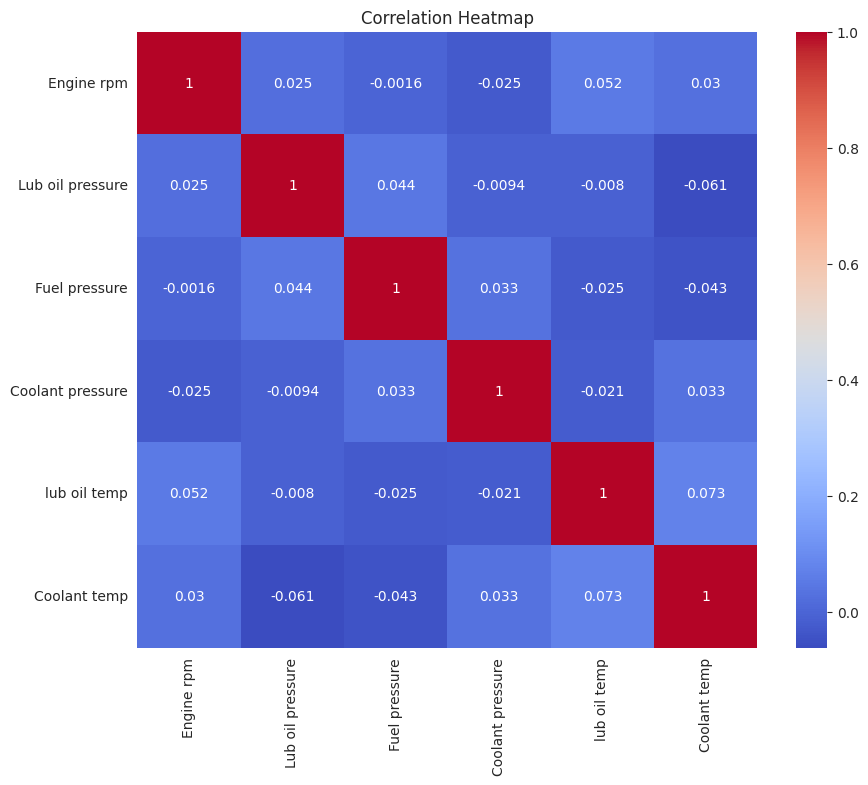

In [130]:
# Correlation Heatmap

corr = data.corr()

fig, axes = plt.subplots(figsize=(10,8))

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.savefig('Correlation_Heatmap_features.png',bbox_inches='tight')
plt.show()



### **Observations**

**Histograms:**
- Most features are right-skewed, meaning a smaller number of high values pull the mean above the median — consistent with the Engine RPM observation above.
- Coolant Temperature is the most symmetrically distributed feature (skewness = 0.40), though its max value of 195°C is dramatically higher than the mean of 78°C, suggesting at least one extreme event in the data.
- Several features (Engine RPM, Lub Oil Temp) appear bimodal — two peaks suggest the engine may operate across two distinct states (e.g., normal cruising vs. high-load operation). This is relevant for anomaly detection: a bimodal distribution means a single IQR threshold may not capture all unusual behaviour.

**Boxplots:**
- All features except Coolant Temperature show numerous extreme values beyond the whiskers, which are strong candidates for anomalies.
- The volume of extreme values in Lubrication Oil Temperature is notable

**Correlation Heatmap:**
- No strong correlations exist between any pair of features. This is a significant finding: it means each sensor is measuring something independently, so single-feature outlier detection (like IQR applied to one variable at a time) will miss anomalies that only emerge when combinations of features behave unusually together.
- This finding directly motivates the multi-feature anomaly detection approach used in this notebook.
        

## **2. Outlier Detection - Statistical Method**

In [131]:

#Calculate IQR for every feature

iqr_of_features = []

for feat in features:
  Q1 = data[feat].quantile(0.25)
  Q3 = data[feat].quantile(0.75)
  IQR = Q3 - Q1
  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR

  feat_col = f'{feat}_outliers'
  data[feat_col] = ((data[feat] < lower_bound) | (data[feat] > upper_bound)).astype(int)

  n_outliers = data[feat_col].sum()
  pct_outliers = 100 * n_outliers / len(data)

  iqr_of_features.append({'Feature': feat,
                          'Q1': Q1,
                          'Q3': Q3,
                          'IQR': IQR,
                          'Lower Bound': lower_bound,
                          'Upper Bound': upper_bound,
                          'Number of Outliers': n_outliers,
                          'Percentage Outliers': pct_outliers})


#Turn into dataframe

iqr_df = pd.DataFrame(iqr_of_features)

iqr_df.round(3)






,Feature,Q1,Q3,IQR,Lower Bound,Upper Bound,Number of Outliers,Percentage Outliers
0,Engine rpm,593.000,934.000,341.000,81.500,1445.500,464,2.375
1,Lub oil pressure,2.519,4.055,1.536,0.214,6.360,66,0.338
2,Fuel pressure,4.917,7.745,2.828,0.675,11.987,1135,5.810
3,Coolant pressure,1.600,2.849,1.248,-0.272,4.721,785,4.018
4,lub oil temp,75.726,78.072,2.346,72.207,81.590,2617,13.396
5,Coolant temp,73.895,82.915,9.020,60.365,96.445,2,0.010


In [132]:
#Binary Column for outliers

#create variable for columns that contain outliers
outlier_cols = [col for col in data.columns if '_outliers' in col]
#show columns
data[features + outlier_cols].head(20)

,Engine rpm,Lub oil pressure,Fuel pressure,Coolant pressure,lub oil temp,Coolant temp,Engine rpm_outliers,Lub oil pressure_outliers,Fuel pressure_outliers,Coolant pressure_outliers,lub oil temp_outliers,Coolant temp_outliers
0,682,2.391656,4.617196,2.848982,76.272417,69.884609,0,0,0,0,0,0
1,605,5.466877,6.424361,5.727520,73.222679,74.907314,0,0,0,1,0,0
2,658,3.434232,3.680896,1.678708,88.089916,78.704806,0,0,0,0,1,0
3,749,2.094656,7.120927,1.639670,77.661625,82.386700,0,0,0,0,0,0
4,676,3.538228,5.956472,3.225336,75.226352,67.153220,0,0,0,0,0,0
5,589,2.933888,6.358464,2.461478,77.534616,75.403745,0,0,0,0,0,0
6,885,2.034509,15.499680,1.522790,78.959645,80.817985,0,0,1,0,0,0
7,576,5.495972,13.114658,1.251058,78.091390,71.934674,0,0,1,0,0,0
8,535,3.159440,8.676361,1.265139,82.408722,80.752747,0,0,0,0,1,0
9,806,3.946885,21.138326,1.572569,74.923316,72.112692,0,0,1,0,0,0


In [133]:
#Count the amount of outliers per feature

outlier_counts = data[outlier_cols].sum()

outlier_counts

,0
Engine rpm_outliers,464
Lub oil pressure_outliers,66
Fuel pressure_outliers,1135
Coolant pressure_outliers,785
lub oil temp_outliers,2617
Coolant temp_outliers,2


In [134]:
#Feature threshold - 1-5% range

#Count how many outliers go across more than one feature

data['outlier_across_features'] = data[outlier_cols].sum(axis=1)

print(data['outlier_across_features'].value_counts())



outlier_across_features
0    14899
1     4214
2      411
3       11
Name: count, dtype: int64


In [135]:
#Find the best threshold

#Create a table for easier viewing


print('Threshold | Number of Outliers | Percentage of Outliers')
print('-' * 40)

best_threshold = None

for t in range(1, len(features) +1):

  #count rows where t or more features are outliers
  num_outliers = 0
  for value in data['outlier_across_features']:
    if value >= t:
      num_outliers += 1

  #Calculate %
  pct = 100 * num_outliers / len(data)

  #Check in target range of 1-5%
  if 1.0 <= pct <= 5.0:
    marker = '   <== In Range'
    if best_threshold is None:
      best_threshold = t
  else:
    marker = ''


  print(f'T={t} | {num_outliers} Outliers | {round(pct,2)}%{marker}')


print(f'Best Threshold: {best_threshold}')

data['iqr_anomaly'] = (data['outlier_across_features'] >= best_threshold).astype(int)




Threshold | Number of Outliers | Percentage of Outliers
----------------------------------------
T=1 | 4636 Outliers | 23.73%
T=2 | 422 Outliers | 2.16%   <== In Range
T=3 | 11 Outliers | 0.06%
T=4 | 0 Outliers | 0.0%
T=5 | 0 Outliers | 0.0%
T=6 | 0 Outliers | 0.0%
Best Threshold: 2


### **IQR Method — Observations and Effectiveness**

**Results summary:**
- At T=1 (flagging any point with at least one outlier feature), 23.73% of the data is flagged — far too high for a practical anomaly detector and inconsistent with the expected 1–5% anomaly rate.
- At T=2 (flagging points where two or more features simultaneously show outlier values), 2.16% of data is flagged — within the 1–5% target range.
- At T=3, only 0.06% is flagged — too conservative, likely to miss real anomalies.

**Why T=2 is a reasonable threshold:**
Requiring two features to be simultaneously anomalous aligns with the business context, which warns that single high values (e.g., high RPM alone) may reflect normal operating conditions like acceleration. When multiple sensors deviate at the same time, this is a stronger signal of a genuine problem.

**Notable per-feature findings:**
- lub oil temp has the highest single-feature outlier rate at 13.4%, driven by its very narrow IQR (2.35°C). The bounds are tight, so moderate deviations are flagged.
- Coolant temp has almost no outliers (0.01%) at T=1, meaning it contributes very little to anomaly detection on its own. Yet its extreme max value of 195°C may represent a genuinely critical event.

**Limitations of the IQR method:**
- IQR is a univariate method meaning it analyses each feature in isolation. Even with the multi-feature threshold extension used here, it cannot model the relationships between features (e.g., whether a moderate RPM combined with a moderate oil temperature is unusual).
- It is sensitive to the underlying distribution. Skewed or bimodal features (as observed in the EDA) may produce misleading bounds.


## **3. Anomaly Detection - ML Methods**

### **3.1 Feature Scaling and PCA**

In [136]:
#Prepare data for PCA by standardising

X = data[features]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(X_scaled[:5])


[[-0.40821185 -0.89281929 -0.73830371  0.49559555 -0.44070891 -1.37641176]
 [-0.69595007  2.11733175 -0.08375911  3.27315389 -1.42104681 -0.56715821]
 [-0.49789649  0.12769669 -1.07742594 -0.63362488  3.35802552  0.04469003]
 [-0.15784222 -1.18353441  0.16853314 -0.67129327  0.00585205  0.6379134 ]
 [-0.43063301  0.22949196 -0.25322555  0.85874712 -0.77696641 -1.81649055]]


In [137]:
#Run PCA and reduce component size to 2

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

evr = pca.explained_variance_ratio_

print(f'PC1 : {evr[0]*100}')
print(f'PC2 : {evr[1]*100}')
print(f'Total Explained Variance {sum(evr)*100}')



PC1 : 18.994849662213454
PC2 : 17.69296818369302
Total Explained Variance 36.68781784590647


### **PCA — Explained Variance**

The two principal components together explain only 36.7% of the total variance in the dataset (PC1: 19.0%, PC2: 17.7%). This is relatively low, and it means the 2D plot discards roughly 63% of the information contained in the original 6 features.

Anomalies detected by the models (which operate on all 6 features) may not always appear visually separated from the normal cluster in the 2D PCA plot. Some anomalies will look normal in 2D because the feature combinations that make them anomalous are captured in the discarded components. This is a known limitation of PCA-based visualisation and will be discussed further when evaluating the plots.

### **3.2. One-Class SVM**

In [138]:
#Run SVM with gamma = scale, nu = 0.05

model = OneClassSVM(kernel='rbf', gamma='scale', nu=0.05)
model.fit(X_scaled)

OneClassSVM(nu=0.05)

In [139]:
#Predict the class

y_pred = model.predict(X_scaled)
print(y_pred)

[ 1 -1  1 ...  1  1  1]


In [140]:
#Turn into a database for easy viewing

df = pd.DataFrame(X_scaled, columns = features)
df['Anomaly'] = y_pred
df



,Engine rpm,Lub oil pressure,Fuel pressure,Coolant pressure,lub oil temp,Coolant temp,Anomaly
0,-0.408212,-0.892819,-0.738304,0.495596,-0.440709,-1.376412,1
1,-0.695950,2.117332,-0.083759,3.273154,-1.421047,-0.567158,-1
2,-0.497896,0.127697,-1.077426,-0.633625,3.358026,0.044690,1
3,-0.157842,-1.183534,0.168533,-0.671293,0.005852,0.637913,1
4,-0.430633,0.229492,-0.253226,0.858747,-0.776966,-1.816491,1
...,...,...,...,...,...,...,...
19530,-0.411949,0.288774,0.233701,-1.208058,-0.461752,-1.382184,1
19531,-0.789372,-1.038290,-0.511826,-0.833709,-0.243824,1.397013,1
19532,-0.654845,0.006141,-1.038745,3.537070,-0.563698,-1.000134,1
19533,1.389218,-0.559945,-1.069205,0.594695,-0.276059,0.478951,1


In [141]:
#Calculate amount of anomalies

anomalies = df[df['Anomaly'] == -1]
print(f'Number of anomalies: {len(anomalies)}')

pct = 100 * len(anomalies) / len(df)
#If
if 1.0 <= pct <= 5.0:
  print(f'Number of anomalies fits threshold: {pct}%')
else:
  print(f'Number of anomalies does not fit threshold: {pct}%')



Number of anomalies: 976
Number of anomalies fits threshold: 4.996160737138469%


In [142]:
#Finding the best nu to use

nu_values = np.arange(0.01, 0.11, 0.01)
anomaly_rate = []

for nu in nu_values:
  model = OneClassSVM(nu=nu, kernel='rbf', gamma='scale')
  model.fit(X_scaled)
  predictions = model.predict(X_scaled)
  anom_rate = (predictions == -1).mean() * 100
  anomaly_rate.append(anom_rate)

anomaly_rates_df = pd.DataFrame({
    'Nu Value': nu_values,
    'Anomaly Rate (%)': anomaly_rate})

display(anomaly_rates_df.round(3))



,Nu Value,Anomaly Rate (%)
0,0.01,1.014
1,0.02,2.048
2,0.03,2.995
3,0.04,4.018
4,0.05,4.996
5,0.06,6.040
6,0.07,7.013
7,0.08,7.996
8,0.09,8.999
9,0.10,10.003


### **NU Values**

nu=0.01 is picked for our One-Class SVM model. This is the lowest value of nu where the anomaly rate still fits with the parameter of 1-5%. This is the most conservative choice, but it reduces the potential of false positives in our model. The same will be done when we choose a contamination level for Isolation Forest.








In [143]:
#Train one class SVM on nu=0.01

svm_best_model = OneClassSVM(nu=0.01, kernel='rbf', gamma='scale')
svm_best_model.fit(X_scaled)
predictions = svm_best_model.predict(X_scaled)

#Create column in dataframe for anomaly predictions

data['SVM Anomaly'] = (predictions == -1).astype(int)

n_svm_anom = data['SVM Anomaly'].sum()
pct_svm_anom = 100 * n_svm_anom / len(data)

print(f'Number of anomalies: {n_svm_anom}')
print(f'Percentage of anomalies: {pct_svm_anom}%')

Number of anomalies: 198
Percentage of anomalies: 1.0135653954440746%


In [144]:
#Plot One Class SVM model with PCA


def plot_model(model, X_scaled, title):
    # Create a grid for plotting decision boundaries and anomaly detection.
    x_min, x_max = X_scaled[:, 0].min() - 1, X_scaled[:, 0].max() + 1
    y_min, y_max = X_scaled[:, 1].min() - 1, X_scaled[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max), np.linspace(y_min, y_max))
    Z = model.decision_function(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Predict whether each point is an inlier (1) or an outlier (-1).
    y_pred = model.predict(X_scaled)

    # Plot setup.
    plt.figure(figsize=(10, 8))
    plt.title(title)

    # Plot the decision function levels and decision boundary.
    plt.contourf(xx, yy, Z, levels=np.linspace(Z.min(), 0, 7), cmap=plt.cm.PuBu, alpha=0.8)
    plt.contour(xx, yy, Z, levels=[0], linewidths=2, colors='darkred')  # Decision boundary
    plt.contourf(xx, yy, Z, levels=[0, Z.max()], colors='palevioletred', alpha=0.5)  # Anomaly regions

    # Plot also the data points, using different markers for normals and anomalies.
    sns.scatterplot(x=X_scaled[:, 0], y=X_scaled[:, 1], hue=np.where(y_pred == 1, 'Normal', 'Anomaly'),
                    style=np.where(y_pred == -1, 'Anomaly', 'Normal'), markers={'Anomaly': 'X', 'Normal': 'o'},
                    palette={'Normal': 'deepskyblue', 'Anomaly': 'red'}, alpha=0.6, edgecolor='k')

    # Plot aesthetics.
    plt.axis('tight')
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.legend()
    plt.savefig('OneClassSVM_PCA.png', bbox_inches='tight')
    plt.show()

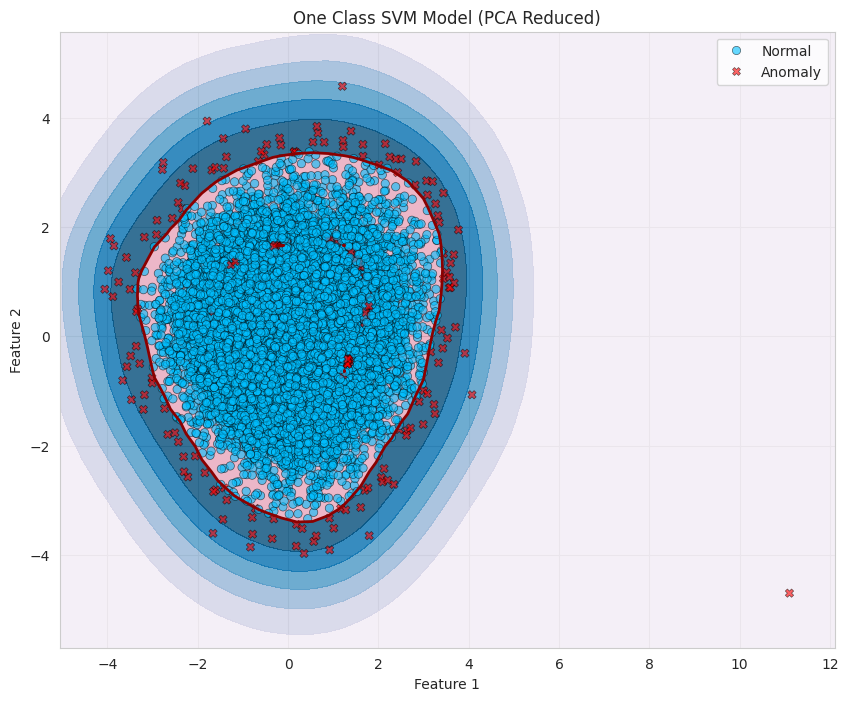

In [145]:
# Train a OneClassSVM model specifically for plotting with 2 PCA components
svm_pca_model = OneClassSVM(nu=0.01, kernel='rbf', gamma='scale')
svm_pca_model.fit(X_pca) # Fit on 2 PCA components

# Then call the plot function with this new model and the PCA-transformed data
plot_model(svm_pca_model, X_pca, 'One Class SVM Model (PCA Reduced)')

 ### **One-Class SVM with PCA Visual**

 - Anomalies far from the centre in PCA space represent the most severe deviations from normal — these should be prioritised for maintenance checks
- The model is conservative (nu=0.01) meaning it only flags the clearest anomalies, reducing false alarms for the engineering team
- The well-separated clusters suggest the 6 engine features together provide a strong signal for detecting abnormal behaviour

### **3.3. Isolation Forest**

In [146]:
# Find the best contamination
best_contamination= []

for cont in [0.01, 0.02, 0.03, 0.04, 0.05]:
  iso_forest = IsolationForest(contamination=cont, random_state=42, n_estimators=200)
  iso_forest.fit(X_scaled)
  y_pred = iso_forest.predict(X_scaled)
  n_anomalies = (y_pred == -1).sum()
  pct_anomalies = 100 * n_anomalies / len(data)

  # Append the results to best_contamination
  best_contamination.append({'Contamination': cont, 'Number of Anomalies': n_anomalies, 'Percentage of Anomalies': pct_anomalies})

# Convert to a DataFrame for easier viewing
iso_df = pd.DataFrame(best_contamination)
display(iso_df)

,Contamination,Number of Anomalies,Percentage of Anomalies
0,0.01,196,1.003327
1,0.02,391,2.001536
2,0.03,587,3.004863
3,0.04,782,4.003071
4,0.05,977,5.001280


### **Contamination Value**

As with nu value for One-Class SVM, we select the lowest contamination value that still fits the parameter of 1-5% anomalies. This reduces the chance of false positives in our analysis.



In [147]:
iso_forest_best = IsolationForest(contamination=0.01, random_state=42, n_estimators=200)
iso_forest_best.fit(X_scaled)
y_pred = iso_forest_best.predict(X_scaled)

data['IsolationForest Anomaly'] = (y_pred == -1).astype(int)

n_iso_anomalies = (y_pred == -1).sum()
iso_anom_pct = 100 * n_iso_anomalies / len(data)

print(f'Number of anomalies: {n_iso_anomalies}')
print(f'Percentage of anomalies: {iso_anom_pct}%')
print(f'Contamination rate: 0.01')

Number of anomalies: 196
Percentage of anomalies: 1.0033273611466598%
Contamination rate: 0.01


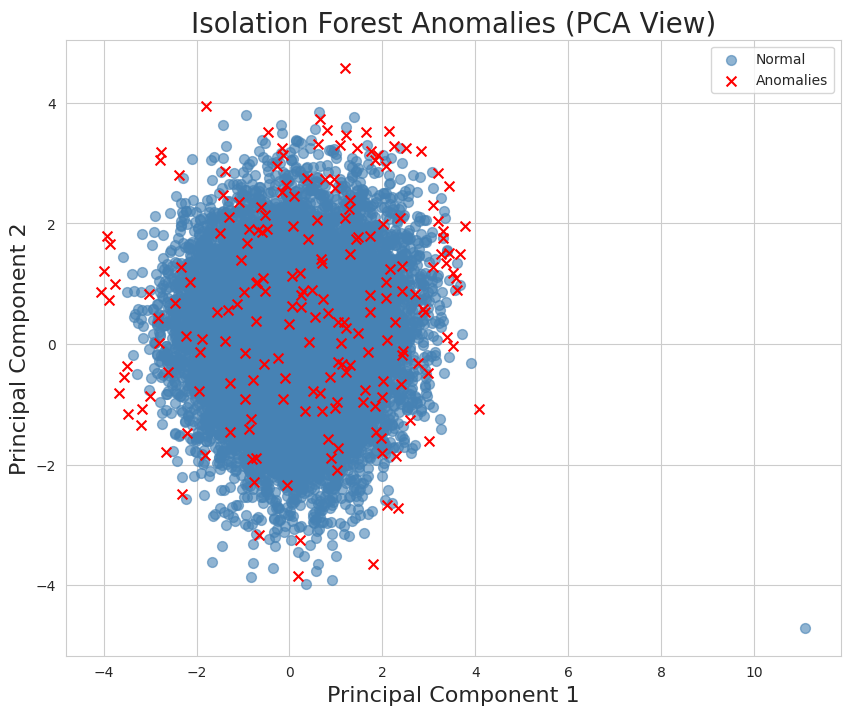

In [148]:
plt.figure(figsize=(10, 8))

anomaly_mask = data['IsolationForest Anomaly'] == 1
# Plot normal points
plt.scatter(X_pca[~anomaly_mask, 0],
            X_pca[~anomaly_mask, 1],
            label='Normal',
            c='steelblue',
            s=50,
            alpha=0.6)

# Plot anomalies on top in red
plt.scatter(X_pca[anomaly_mask, 0],
            X_pca[anomaly_mask, 1],
            c='red',
            s=50,
            marker='x',
            label='Anomalies')



plt.title("Isolation Forest Anomalies (PCA View)", fontsize=20)
plt.xlabel('Principal Component 1', fontsize=16)
plt.ylabel('Principal Component 2', fontsize=16)
plt.legend()
plt.savefig('IsolationForest_PCA.png', bbox_inches='tight')
plt.show()

### **Isolation Forest with PCA Analysis**


**Comparison to One-Class SVM:**
- Both models identify a similar subset of anomalies, providing cross-validation of the findings.
- Differences between the two models highlight edge-case data points that are borderline anomalous — these warrant further investigation by domain experts.


**Effectiveness of PCA Plots:**

- The plots are effective at showing the clustering of normal data and the positioning of anomalies relative to that cluster. Clear separation of anomaly points (red) from the main cluster (blue) provides visual confirmation that the models are detecting genuinely extreme data points.
- However, 63% of the variance is discarded, meaning a number of anomalies detected in the full 6D space may not appear visually separated in 2D. This is a known limitation of PCA-based visualisation.

## **4. Cross Method Comparison**

In [149]:
#See where all 3 methods of outlier and anomaly detection agree

data['All Agree Anomaly'] = ((data['iqr_anomaly']== 1) & (data['SVM Anomaly']== 1) & (data['IsolationForest Anomaly']==1)).astype(int)
data['Two Agree Anomaly'] = ((data['iqr_anomaly'] + data['SVM Anomaly'] + data['IsolationForest Anomaly']) >= 2).astype(int)

comparison_df = pd.DataFrame({'Method': ['IQR', 'SVM', 'IsoForest', 'All Agree', 'Two Agree'],
                              'Number of anomalies': [
                                  data['iqr_anomaly'].sum(),
                                  data['SVM Anomaly'].sum(),
                                  data['IsolationForest Anomaly'].sum(),
                                  data['All Agree Anomaly'].sum(),
                                  data['Two Agree Anomaly'].sum()
                                                      ]})
comparison_df['Anomaly pct'] = 100 * comparison_df['Number of anomalies'] / len(data)
comparison_df.round(2)
display(comparison_df)

,Method,Number of anomalies,Anomaly pct
0,IQR,422,2.160225
1,SVM,198,1.013565
2,IsoForest,196,1.003327
3,All Agree,58,0.296903
4,Two Agree,176,0.900947


### **Key observations:**



- **IQR flags 422 anomalies (2.16%)**: This is higher than the ML methods because IQR applies fixed statistical bounds per feature independently, without learning the shape of the overall data distribution. It is more likely to flag borderline cases.

- **One-Class SVM and Isolation Forest agree closely (198 vs 196 anomalies)**: Despite being fundamentally different algorithms, they converge on almost the same number of anomalies. This mutual agreement strengthens confidence in those findings.

- **176 anomalies are flagged by at least two methods**. This represents a mid-confidence tier. These are data points where independent approaches corroborate each other. These are strong candidates for scheduled inspection by the engineering team.

- **Only 58 anomalies are flagged by all three methods simultaneously.** These are the highest-confidence anomalies in the dataset. These are cases where a statistical method and two independent ML models all agree. These 58 readings should be the immediate priority for the engineering team, as the probability of a false positive is very low.
 experts.

- **The divergence between IQR (422) and the ML methods (~197) is expected**: IQR cannot capture multivariate structure, so it flags many single-feature extremes that the ML models, operating across all six features simultaneously, do not consider genuinely anomalous; these are outliers.

### **4.1. Statistics of anomalies vs normal**

In [150]:
# Using Isolation Forest anomalies as the primary flag

anomalies = data[data['IsolationForest Anomaly'] == 1][features]
normal = data[data['IsolationForest Anomaly'] == 0][features]

comparison = pd.DataFrame({
    'Normal Mean': normal.mean().round(3),
    'Anomaly Mean': anomalies.mean().round(3),
    'Difference': (anomalies.mean() - normal.mean()).round(3),
    '% Change': (((anomalies.mean() - normal.mean()) / normal.mean()) * 100).round(1)
})

comparison

,Normal Mean,Anomaly Mean,Difference,% Change
Engine rpm,788.534,1058.133,269.598,34.2
Lub oil pressure,3.302,3.449,0.147,4.4
Fuel pressure,6.617,10.513,3.897,58.9
Coolant pressure,2.323,3.602,1.279,55.1
lub oil temp,77.598,82.121,4.523,5.8
Coolant temp,78.420,79.161,0.741,0.9


### **5. Anomaly Profiling Observations**

- **Fuel Pressure shows the largest deviation at +58.9% above normal (6.62 > 10.51)**. This is the strongest single driver of anomalous behaviour. Elevated fuel pressure of this magnitude is consistent with fuel pump or filter issues, which can cause poor combustion and injector damage.

- **Coolant Pressure is the second largest contributor at +55.1% above normal (2.32 > 3.60)**. Combined with the elevated fuel pressure, this co-occurrence suggests a potential blockage pattern across both systems simultaneously. Exactly the kind of multi-feature interaction the business context warned would characterise genuine anomalies.

- **Engine RPM is elevated by 34.2% in anomalous readings (789 → 1058)**. This is consistent with the engine being pushed beyond typical operating conditions. As per business context, this leads to overheating, excessive wear and eventual failure.

- **Lubrication Oil Temperature shows a moderate increase of +5.8% (77.6°C → 82.1°C)**, indicating the engine is running warmer than normal.This is a natural consequence of elevated RPM and pressure.

- **Lubrication Oil Pressure and Coolant Temperature show minimal mean differences (+4.4% and +0.9% respectively)**. This suggests these sensors are less central to the anomaly pattern detected, though individual extreme values — such as the Coolant Temperature maximum of 195°C — remain operationally significant outliers worth flagging separately.